In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('fruits.csv')
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
# Weight (is in int64), Size (is in float64) , Class (is in the object) -> means in the classification

In [5]:
df.isna().sum() # For finding the null value

Weight    0
Size      0
Class     0
dtype: int64

In [6]:
df['Class'].value_counts()

Class
orange    20
apple     20
Name: count, dtype: int64

In [7]:
# Applying the Lable encoding in the Class column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
df.head()

,Weight,Size,Class
0,69,4.39,1
1,69,4.21,1
2,65,4.09,1
3,72,5.85,0
4,67,4.70,1


1 is for Orange
0 is for Apple

In [8]:
# checking the outliers in the dataset if there is any then removing the outliers (Data Cleaning)
df.describe()

,Weight,Size,Class
count,40.000000,40.000000,40.00000
mean,70.200000,4.922750,0.50000
std,3.039906,0.590063,0.50637
min,65.000000,4.010000,0.00000
25%,68.000000,4.360000,0.00000
50%,70.000000,4.930000,0.50000
75%,73.000000,5.472500,1.00000
max,75.000000,5.850000,1.00000


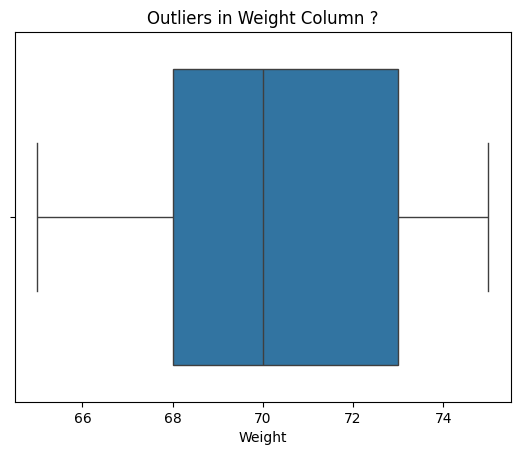

In [9]:
sns.boxplot(x = 'Weight', data = df)
plt.title("Outliers in Weight Column ?")
plt.show()

In [10]:
df.columns

Index(['Weight', 'Size', 'Class'], dtype='object')

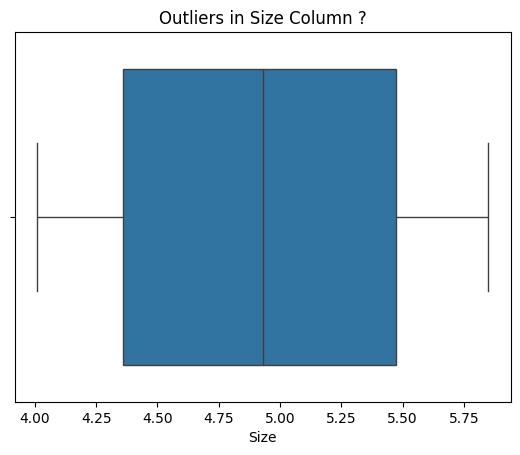

In [11]:
sns.boxplot(x = 'Size', data = df)
plt.title("Outliers in Size Column ?")
plt.show()

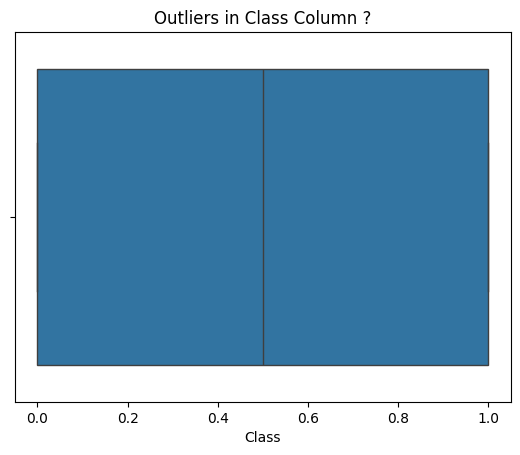

In [12]:
sns.boxplot(x = 'Class', data = df)
plt.title("Outliers in Class Column ?")
plt.show()

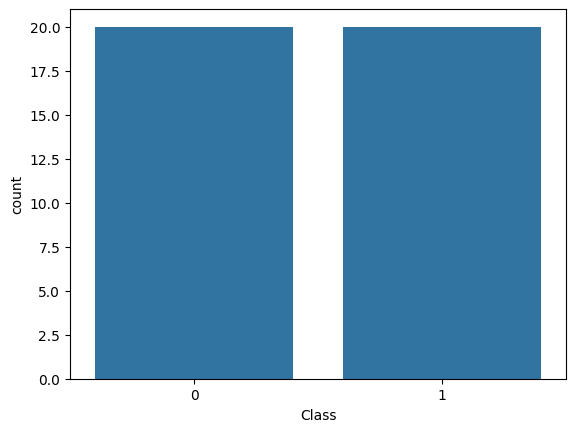

In [13]:
sns.countplot(x = 'Class', data = df)
plt.show()

In [14]:
df.shape

(40, 3)

In [15]:
df.ndim

2

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.1 KB


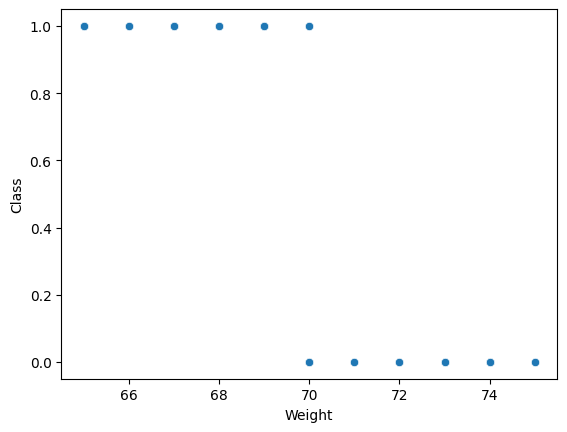

In [20]:
sns.scatterplot(y = 'Class', x = 'Weight', data = df)
plt.show()

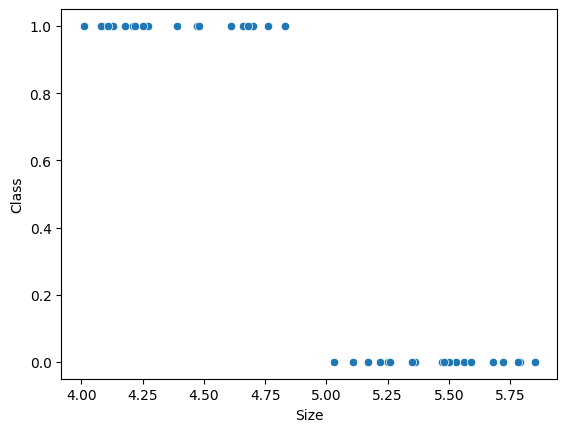

In [21]:
sns.scatterplot(y = 'Class', x = 'Size', data = df)
plt.show()

In [22]:
# Finding the correlation from the dataset
df.corr()

,Weight,Size,Class
Weight,1.000000,0.765027,-0.849528
Size,0.765027,1.000000,-0.900641
Class,-0.849528,-0.900641,1.000000


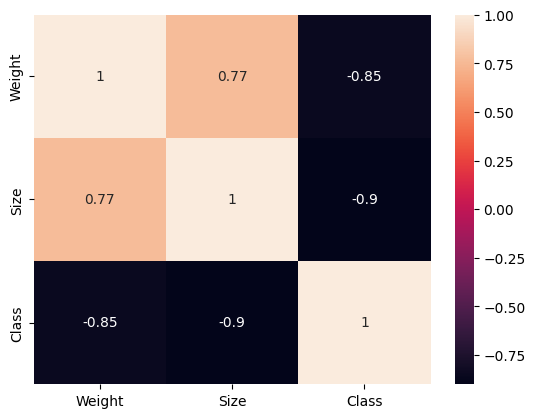

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.show()

In [24]:
# Now going for the train / test split of the dataset
x = df[['Size','Weight']]
y = df['Class']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.10, random_state=10,shuffle=True)

In [25]:
# Now building the machine learning model
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression()
lgr.fit(x_train,y_train)

LogisticRegression()

In [26]:
lgr.coef_

array([[-1.09770002, -1.4611312 ]])

In [27]:
lgr.intercept_

array([107.63466467])

In [28]:
y_pred = lgr.predict(x_test)
y_pred

array([1, 1, 1, 0])

In [29]:
y_test

2     1
27    1
35    1
30    0
Name: Class, dtype: int64

In [30]:
# Finding the accuracy of the matrix
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

1.0

Giving me 100 percent accuracy for this model

In [31]:
# Drawing the confusion matrix for this dataset
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[1, 0],
       [0, 3]])

In [32]:
df.head(4)

,Weight,Size,Class
0,69,4.39,1
1,69,4.21,1
2,65,4.09,1
3,72,5.85,0


In [33]:
# Taking the user input and applying the prediction in the model
user_weight = int(input("Enter the weight: "))
user_Size = float(input("Enter the Size: "))

user_input = [[user_weight,user_Size]]
lgr.predict(user_input)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

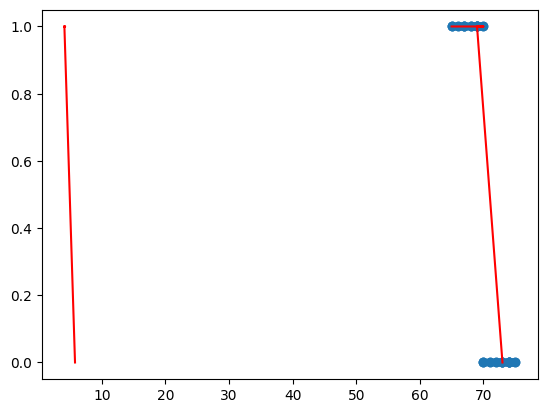

In [36]:
# Drawing the logistic regression line
plt.scatter(x = 'Weight', y = 'Class', data = df)
plt.plot(x_test,y_pred,color='red')
plt.show()

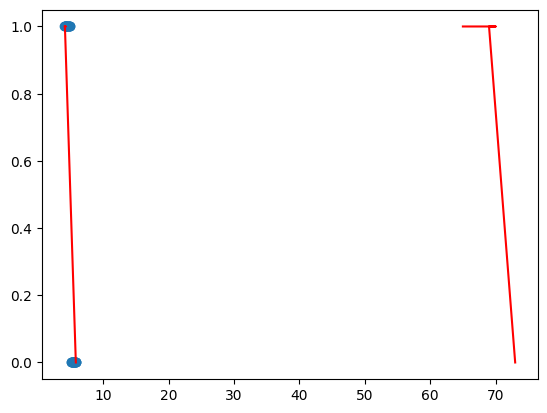

In [42]:
plt.scatter(x = 'Size', y = 'Class', data = df)
plt.plot(x_test,y_pred,color='red')
plt.show()

In [44]:
# Finding the mean absolute error for finding the error in the model
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

0.0

In [45]:
# finding the mean square error for finding the square error in the model
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

0.0

In [46]:
# Finding the root mean square error method for finding any error are there in the model or not ?
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test,y_pred)

0.0

In [43]:
import pickle
pickle.dump(lgr,open('fruits_logistic_regression.pkl','wb'))